In [1]:
!curl -L -O https://github.com/faamaral/ativ-visao-computacional/raw/refs/heads/main/dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 41.8M  100 41.8M    0     0  21.7M      0  0:00:01  0:00:01 --:--:-- 85.5M


In [2]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
   creating: dataset/calca/
  inflating: dataset/calca/calca1.jpg  
  inflating: dataset/calca/calca2.jpg  
  inflating: dataset/calca/calca3.jpg  
  inflating: dataset/calca/calca4.jpg  
  inflating: dataset/calca/calca5.jpg  
   creating: dataset/camisa/
  inflating: dataset/camisa/camisa1.jpg  
  inflating: dataset/camisa/camisa2.jpg  
  inflating: dataset/camisa/camisa3.jpg  
  inflating: dataset/camisa/camisa4.jpg  
  inflating: dataset/camisa/camisa5.jpg  


In [3]:
!pip install opencv-python
!pip install matplotlib

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


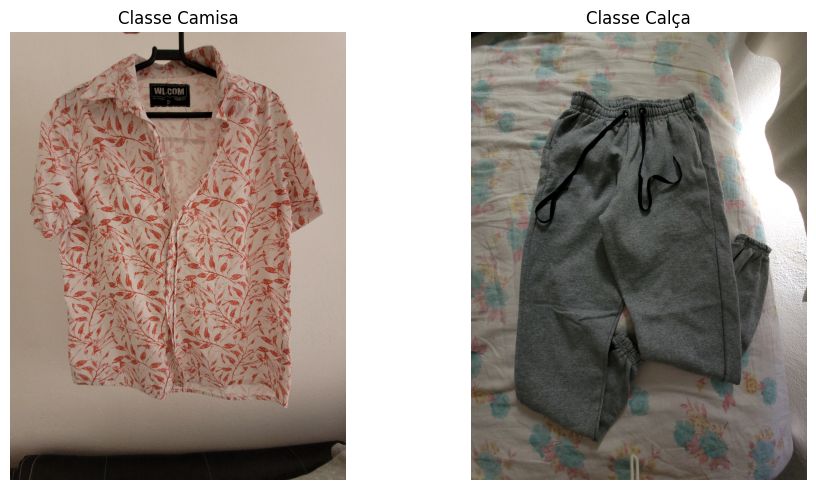

In [6]:
camisa = cv2.cvtColor(cv2.imread("dataset/camisa/camisa1.jpg"), cv2.COLOR_BGR2RGB)
calca = cv2.cvtColor(cv2.imread("dataset/calca/calca1.jpg"), cv2.COLOR_BGR2RGB)

fig, eixos = plt.subplots(1, 2, figsize=(10, 5))
eixos[0].imshow(camisa)
eixos[0].set_title("Classe Camisa")
eixos[1].imshow(calca)
eixos[1].set_title("Classe Calça")

for index in range(2):
  eixos[index].axis("off")
plt.tight_layout()
plt.show()

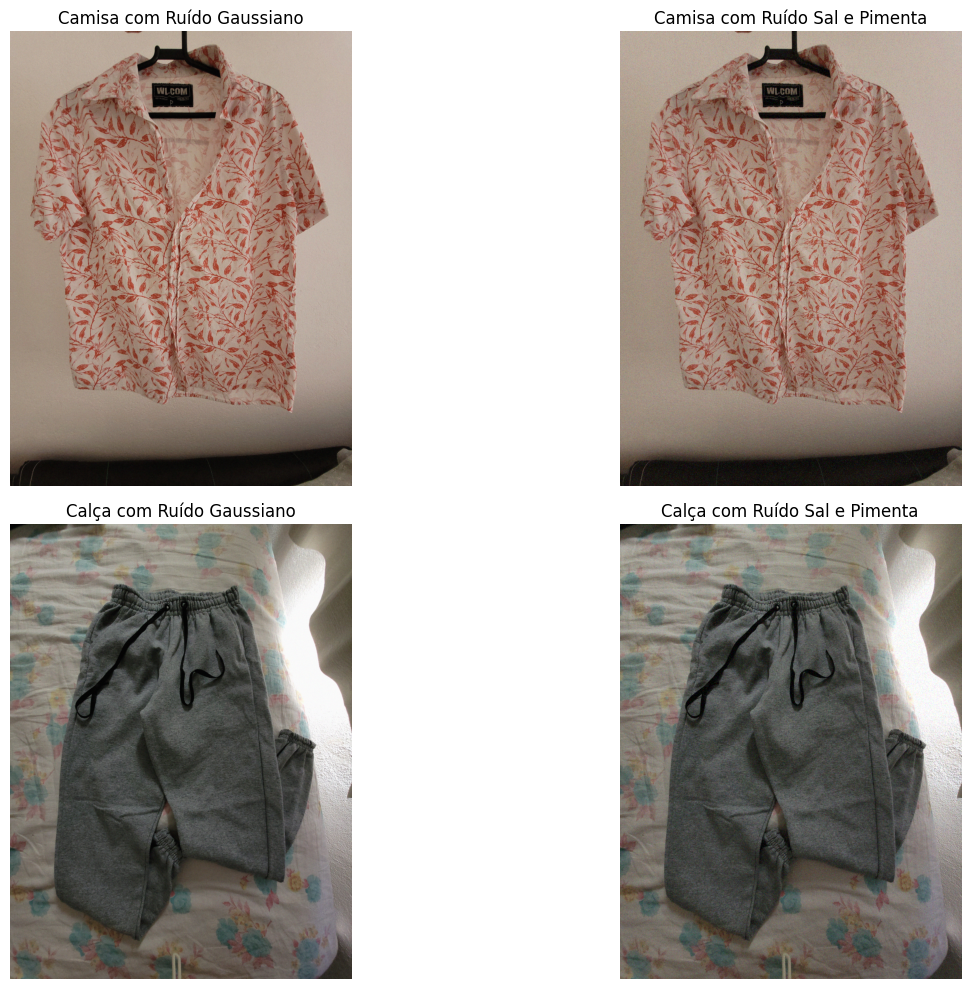

In [9]:
def produzir_ruido_gaussiano(imagem: np.ndarray, sigma: int = 12):
  ruido = np.random.normal(0, sigma, imagem.shape) # gera ruido gaussiano no mesmo formato da imagem
  imagem_ruido = imagem.astype(np.float32) + ruido # adiciona o ruido gerado a imagem
  return np.clip(imagem_ruido, 0, 255).astype(np.uint8) # define os valores dos pixel para valores entre 0 e 255.

def produzir_ruido_sal_pimenta(imagem: np.ndarray, proporcao: float = 0.05):
  saida = imagem.copy() # cria uma copia para preservar a imagem original
  tamanho_ruido = int(proporcao*saida.size) # Calcula quantos pixels serão alterados.
  indices_ruido = np.random.choice(saida.size, tamanho_ruido) # seleciona indices para adicionar ruido de forma aleatoria
  ruido = np.random.choice([saida.min(), saida.max()], tamanho_ruido) # Cria uma lista de ruído com posicionamentos aleatórios dos valores mínimo e máximo dos pixels da imagem.
  saida.flat[indices_ruido] = ruido # Substitui os valores da imagem com ruído modelada em índices aleatórios pelo ruído, para obter a imagem final com ruído.

  return saida

camisa_ruido_gauss = produzir_ruido_gaussiano(camisa)
camisa_sal_pimenta = produzir_ruido_sal_pimenta(camisa)
calca_ruido_gauss = produzir_ruido_gaussiano(calca)
calca_sal_pimenta = produzir_ruido_sal_pimenta(calca)

fig, eixos = plt.subplots(2, 2, figsize=(15, 10))
eixos[0][0].imshow(camisa_ruido_gauss)
eixos[0][0].set_title("Camisa com Ruído Gaussiano")
eixos[0][1].imshow(camisa_sal_pimenta)
eixos[0][1].set_title("Camisa com Ruído Sal e Pimenta")
eixos[1][0].imshow(calca_ruido_gauss)
eixos[1][0].set_title("Calça com Ruído Gaussiano")
eixos[1][1].imshow(calca_sal_pimenta)
eixos[1][1].set_title("Calça com Ruído Sal e Pimenta")
for linha in range(2):
  for coluna in range(2):
    eixos[linha][coluna].axis("off")
plt.tight_layout()
plt.show()
